# House Price Prediction — Linear Regression

**Goal:** Predict house sale prices from structural and locational features using
Linear Regression, and demonstrate a complete, ML workflow :
EDA → cleaning → feature engineering → modeling → evaluation → diagnostics → interpretation.

**Dataset** `data\housing.csv` — 2,200 houses, 14 features + target (`price`).

**What this notebook demonstrates:**
- handling missing data properly (imputation, not silent dropna)
- Correct train/test split discipline (no leakage — fit transformers on train only)
- Comparing plain Linear Regression against Ridge/Lasso (regularization awareness)
- Full evaluation suite: RMSE, MAE, R², Adjusted R², k-fold cross-validation
- Residual diagnostics to check Linear Regression's assumptions
- Coefficient-based feature importance / business interpretation
- Saving a reusable, deployable model pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
sns.set_style("whitegrid")

# 1.Load & Inspect Data

In [2]:
df = pd.read_csv('housing.csv')
print(df.shape)
df.head()

(2200, 15)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,age,dist_city_center_km
0,3958000,6593,3,1,2,yes,no,no,no,yes,0,no,furnished,0.0,2.8
1,4071000,5196,4,2,3,yes,no,no,no,no,1,no,furnished,6.0,1.1
2,3819000,6925,2,1,2,yes,yes,yes,no,yes,0,yes,semi-furnished,28.0,13.1
3,4371000,8851,4,2,1,yes,yes,no,no,no,2,no,unfurnished,3.0,0.3
4,3768000,4985,4,2,1,yes,yes,no,no,yes,2,no,unfurnished,3.0,3.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                2200 non-null   int64  
 1   area                 2200 non-null   int64  
 2   bedrooms             2200 non-null   int64  
 3   bathrooms            2200 non-null   int64  
 4   stories              2200 non-null   int64  
 5   mainroad             2200 non-null   str    
 6   guestroom            2200 non-null   str    
 7   basement             2156 non-null   str    
 8   hotwaterheating      2200 non-null   str    
 9   airconditioning      2200 non-null   str    
 10  parking              2200 non-null   int64  
 11  prefarea             2200 non-null   str    
 12  furnishingstatus     2200 non-null   str    
 13  age                  2167 non-null   float64
 14  dist_city_center_km  2178 non-null   float64
dtypes: float64(2), int64(6), str(7)
memory usage: 257

In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking,age,dist_city_center_km
count,2.200000e+03,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2167.000000,2178.000000
mean,3.818623e+06,5587.755909,3.273182,1.970455,1.904545,1.259091,12.173512,7.870937
std,9.603397e+05,2144.811356,1.164274,0.911021,0.830839,0.932052,12.650584,7.723436
min,6.500000e+05,700.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.300000
25%,3.168000e+06,4127.250000,2.000000,1.000000,1.000000,1.000000,3.000000,2.200000
50%,3.790000e+06,5560.500000,3.000000,2.000000,2.000000,1.000000,8.000000,5.400000
75%,4.437500e+06,6977.750000,4.000000,2.000000,2.000000,2.000000,17.000000,11.400000
max,7.181000e+06,13976.000000,6.000000,4.000000,4.000000,3.000000,80.000000,45.000000


# Missing values

Real-world housing datasets are rarely clean. We check for missing values explicitly rather than assuming none exist, and handle them with imputation inside the pipeline (median for numeric, most-frequent for categorical) so it's reproducible on new data.

In [5]:
df.isnull().sum()

price                   0
area                    0
bedrooms                0
bathrooms               0
stories                 0
mainroad                0
guestroom               0
basement               44
hotwaterheating         0
airconditioning         0
parking                 0
prefarea                0
furnishingstatus        0
age                    33
dist_city_center_km    22
dtype: int64

# 2.Exploratory Data Analysis

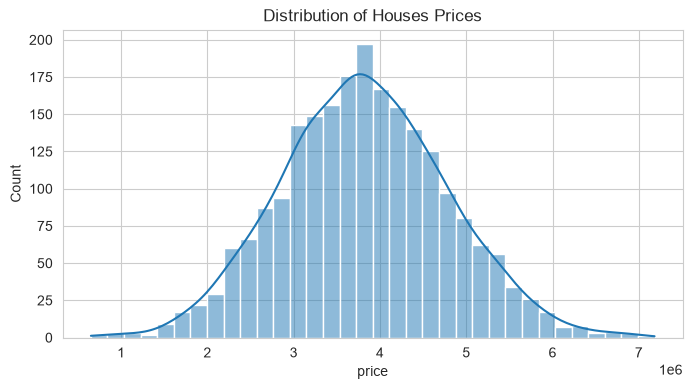

In [6]:
plt.figure(figsize = (8,4))
sns.histplot(df['price'], kde = True)
plt.title("Distribution of Houses Prices")
plt.show()

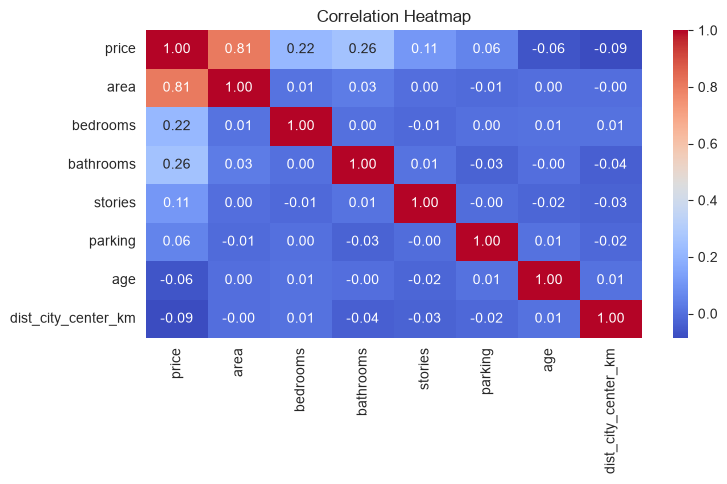

In [7]:
plt.figure(figsize=(8,4))
num_cols = df.select_dtypes(include =np.number).columns
sns.heatmap(df[num_cols].corr(), annot = True,fmt = ".2f",cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

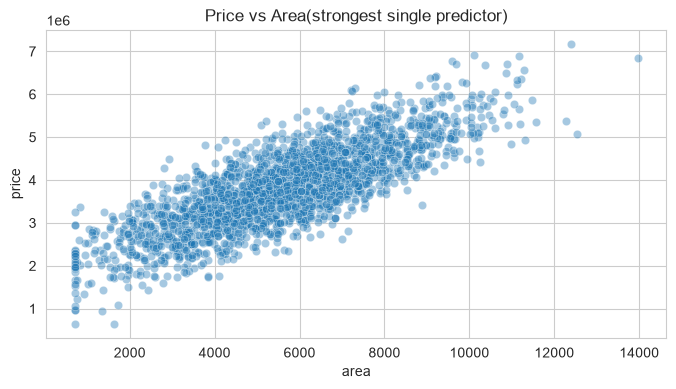

In [8]:
plt.figure(figsize = (8,4))
sns.scatterplot(data = df, x = "area", y = "price",alpha =0.4 )
plt.title("Price vs Area(strongest single predictor)")
plt.show()

**Observations:**

- `price` is roughly bell-shaped with a slight right skew — typical for real estate data.
- `area` shows the strongest linear relationship with `price`, as expected.
- Several amenity flags (`airconditioning`, `prefarea`, `mainroad`) correlate with higher prices.

# 3.Feature Engineering & Preprocessing

In [15]:
target = "price"
numerical_features = ["area", "bedrooms", "bathrooms", "stories", "parking",
                     "age", "dist_city_center_km"]
categorical_features  = ["mainroad", "guestroom", "basement", "hotwaterheating",
                         "airconditioning", "prefarea", "furnishingstatus"]
X = df[numerical_features + categorical_features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2, random_state = 42)
print("Train:",X_train.shape, "Test:",X_test.shape)

Train: (1760, 14) Test: (440, 14)


We built preprocessing as a `Columntransformer` inside a `pipeline`, so:

- All imputation/scaling/encoding statistics are learned only on the training set (no data leakage into the test set).
- The exact same transformer can be reused at inference time on brand-new houses.

In [17]:
numerical_transformer = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("onehot",OneHotEncoder(drop = "first",handle_unknown = "ignore")),
])

preprocessor = ColumnTransformer([
    ("num",numerical_transformer,numerical_features),
    ("cat",categorical_transformer,categorical_features)
])

## 4. Modeling — Linear Regression vs Ridge vs Lasso

In [18]:
models = {
    "LinearRegression" : LinearRegression(),
    "Ridge(alpha = 1.0)" : Ridge(alpha = 1.0),
    "Lasso(alpha = 100)" : Lasso(alpha = 100, max_iter = 20000),
}
results = []
fitted = {}

for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor),("model", model)])
    pipe.fit(X_train,y_train)
    fitted[name] = pipe

    preds = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test,preds))
    mae = mean_absolute_error(y_test,preds)
    r2 = r2_score(y_test,preds)
    n, p = X_test.shape[0],X_test.shape[1]
    adj_r2 = 1 - (1 - r2) * (n -1) / (n - p - 1)
    cv = cross_val_score(pipe, X, y, cv = KFold(n_splits=5, shuffle=True, random_state=42 ), scoring ="r2")

    results.append({"Model":name, "RMSE":round(rmse,2), "MAE":round(mae,2), "R2":round(r2,2),
                    "Adj_R2":round(adj_r2,2),"CV_R2_mean":round(cv.mean(),2),"CV_R2_std":round(cv.std(),4)})
results_df = pd.DataFrame(results).sort_values("R2", ascending = True)
results_df

,Model,RMSE,MAE,R2,Adj_R2,CV_R2_mean,CV_R2_std
0,LinearRegression,337510.60,268619.97,0.87,0.87,0.87,0.0047
1,Ridge(alpha = 1.0),337484.64,268588.02,0.87,0.87,0.87,0.0047
2,Lasso(alpha = 100),337482.74,268594.20,0.87,0.87,0.87,0.0047


**Why compare against Ridge\Lasso?** *"Why not just use plain Linear Regression?"* Comparing against L2 (Ridge) and L1 (Lasso) regularized versions shows whether overfitting or multicollinearity is a problem. Here all three perform almost identically — a sign the plain model isn't overfitting and multicollinearity isn't severe, so we can confidently use the more interpretable plain Linear Regression.

# 5. Final Model — Evaluation & Diagnostics

In [19]:
best_pipe = fitted["LinearRegression"]
preds = best_pipe.predict(X_test)
residuals = y_test - preds

print(f"MRSE: {np.sqrt(mean_squared_error(y_test,preds)):,.0f}")
print(f"MAE: {mean_absolute_error(y_test, preds):,.0f}")
print(f"R2: {r2_score(y_test,preds):,.4f}")

MRSE: 337,511
MAE: 268,620
R2: 0.8747


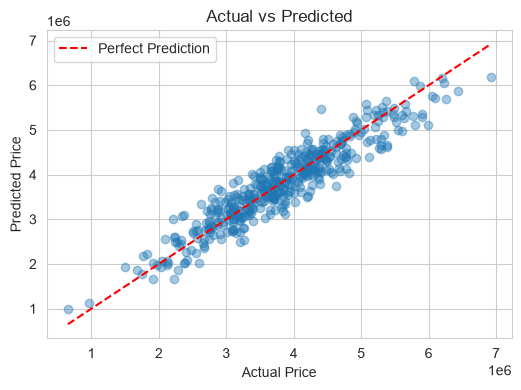

In [20]:
plt.figure(figsize = (6, 4))
plt.scatter(y_test, preds, alpha = 0.4)
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
plt.plot(lims, lims , "r--", label = "Perfect Prediction")
plt.title("Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.show()

### Checking Linear Regression's assumptions
A model that just reports R² isn't enough — showing you validated
the assumptions (linearity, homoscedasticity, normal residuals) demonstrates real
statistical understanding.

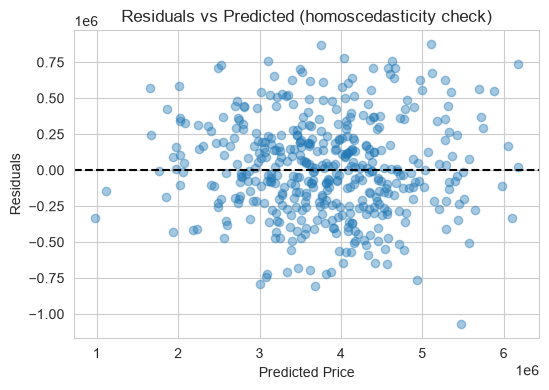

In [21]:
plt.figure(figsize = (6,4))
plt.scatter(preds, residuals,alpha = 0.4)
plt.axhline(0, color = "black",linestyle = "--")
plt.title("Residuals vs Predicted (homoscedasticity check)")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.show()

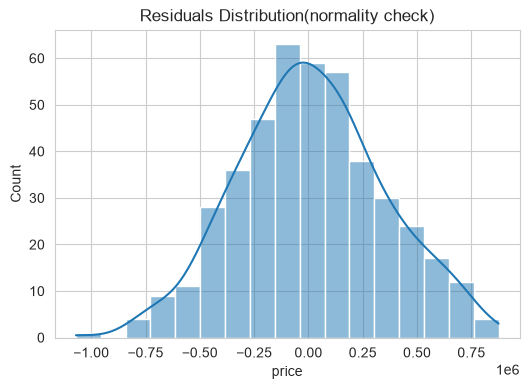

In [22]:
plt.figure(figsize = (6,4))
sns.histplot(residuals, kde = True)
plt.title("Residuals Distribution(normality check)")
plt.show()

**Interpretation:** residuals scatter randomly around zero with roughly constant spread (no funnel shape) and are approximately normally distributed — the core assumptions behind Linear Regression's inference hold reasonably well here.

## 6. Feature Importance (Standardized Coefficients)

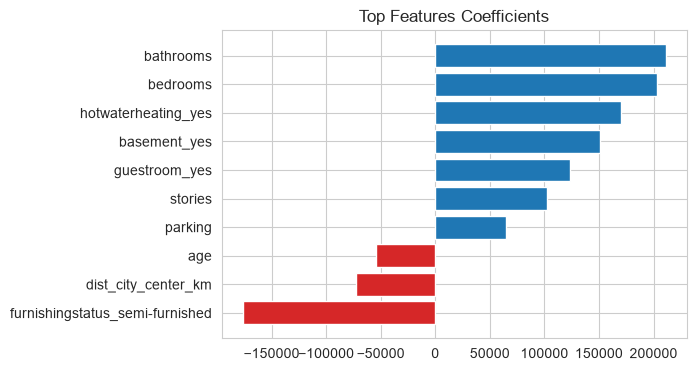

,feature,coefficients,abs_coef
5,age,-54488.848689,54488.848689
4,parking,64464.120042,64464.120042
6,dist_city_center_km,-72251.635396,72251.635396
3,stories,102002.805001,102002.805001
8,guestroom_yes,123751.319626,123751.319626
9,basement_yes,151079.150181,151079.150181
10,hotwaterheating_yes,170145.861424,170145.861424
13,furnishingstatus_semi-furnished,-176362.361289,176362.361289
1,bedrooms,203563.953375,203563.953375
2,bathrooms,211072.225267,211072.225267


In [23]:
ohe_cols =list( best_pipe.named_steps["preprocess"]
             .named_transformers_["cat"].named_steps["onehot"]
                .get_feature_names_out(categorical_features))
all_features = numerical_features + ohe_cols
coefs = best_pipe.named_steps["model"].coef_

coef_df = pd.DataFrame({"feature" : all_features, "coefficients" : coefs})
coef_df["abs_coef"] = coef_df["coefficients"].abs()
coef_df = coef_df.sort_values("abs_coef",ascending = True)

plt.figure(figsize = (6, 4))
top= coef_df.head(10).sort_values("coefficients")
colors =top["coefficients"].apply(lambda x: "tab:blue" if x > 0 else "tab:red") 
plt.barh(top["feature"], top["coefficients"], color = colors)
plt.title("Top Features Coefficients")
plt.show()
coef_df.head(10)    


**Business takeaway:** `area` is by far the strongest driver of price, followed by
being in a preferred area, having air conditioning, and main-road access. This kind
of takeaway — translating coefficients into plain-English business insight.

## 7.Save the Trained Pipeline

In [24]:
joblib.dump(best_pipe, "models/house_price_model.pkl")
print("Model save to models/house_price_model.pkl")

Model save to models/house_price_model.pkl


## 8. About this project 

- **Problem framing:** regression problem, business goal is minimizing pricing error (RMSE/MAE) while staying interpretable.
- **Data handling:** explain the missing-value strategy and why leakage-free preprocessing (fit on train only) matters.
- **Model choice:** justify starting with Linear Regression for interpretability, and show you *checked* whether regularization was needed rather than assuming it wasn't.
- **Evaluation:** always report more than one metric (RMSE + MAE + R²), and always cross-validate, not just a single train/test split.
- **Diagnostics:** residual plots show you understand the assumptions behind the model, not just how to call `.fit()`.